# Image classifier

## Importación de librerías y paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Modelado
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import set_random_seed
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings


### Definición de la semilla y los directorios de train y test

In [8]:
#set_random_seed(24)
data_dir_train = os.path.abspath(os.path.join(os.getcwd(), '..','..', 'dogs_vs_cats', 'train'))
data_dir_test = os.path.abspath(os.path.join(os.getcwd(), '..','..', 'dogs_vs_cats', 'test'))

In [9]:
warnings.filterwarnings('ignore', category=FutureWarning, module='tensorflow')
warnings.filterwarnings('ignore', message='.*deprecated.*')

## Propuesta: utilizar un modelo de redes neuronales para solucionar un problema de clasificación de imágenes

## Generación del conjunto de train y test: utilizamos un elemento `ImageDataGenerator` para crear los conjuntos de train y test

### Train

In [10]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

train_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=(128, 128),  
    batch_size=32,
    class_mode='categorical',     
    subset='training',
    seed=24
    )

Found 16000 images belonging to 2 classes.


### Validación

In [11]:
val_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=24
    )


Found 4000 images belonging to 2 classes.


### Obtener las primeras imágenes del conjunto de train

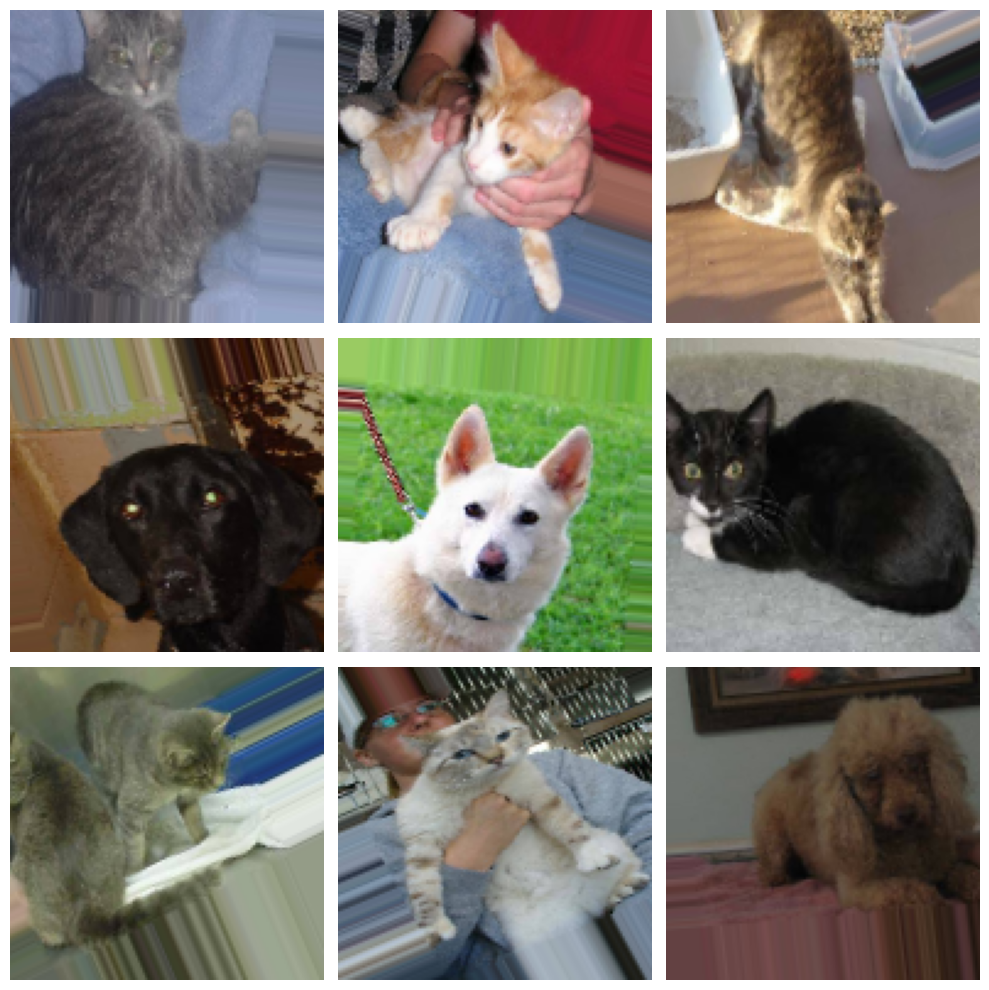

In [15]:
# Obtener un lote del generador
images, labels = next(train_generator)  # Siguiente lote

# Mostrar las primeras 9 imágenes
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Test

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    data_dir_test,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',   # Usar el mismo class_mode que en entrenamiento
    shuffle=False,              # Importante para evaluar o predecir
    seed=24
    )

Found 5000 images belonging to 2 classes.


#### Generamos el conjunto de train y test con `class_mode='categorical'` por que el modelo espera que los datos esten codificados en one-hot

## Generación y ajuste del modelo

#### Definición de arquitectura `VGG16`

In [8]:
"""model = Sequential()
model.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))"""

'model = Sequential()\nmodel.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))\nmodel.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))\nmodel.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))\nmodel.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))\nmodel.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))\nmodel.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))\nmodel.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))\nmodel.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))\nmodel.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))\nmodel.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))\nmodel.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))\nmodel.add(Conv2D(filters = 512,

#### Arquitectura resumida

In [9]:
model = Sequential()
# Entrada
model.add(Input(shape=(128, 128, 3)))
# 1era capa oculta
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
# 2da capa oculta
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
# 3era capa oculta
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
# 4ta capa oculta
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
# Salida
model.add(Dense(2, activation='softmax'))


#### Compilamos: elegimos la función de pérdida `categorical_crossentropy` ya que la capa de salida utiliza una función de activación softmax, la cual espera que los datos esten codificados en one-hot y esta es la función de perdida que corresponde a ese tipo de salida y datos

In [10]:
model.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics = ["accuracy"])
model

<Sequential name=sequential, built=True>

#### Generamos un callback de early_stop

In [11]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True
                           )

#### Generamos un callback de checkpoint

In [ ]:
"""checkpoint = ModelCheckpoint(
    filepath='../sayons-intro-ml-new/models/keras_128x128-16-32_64-64-2.keras',     # Ruta para guardar el modelo
    monitor='val_loss',             # Métrica que observará
    save_weights_only= False,
    save_best_only=True,            # Solo guarda si mejora
    mode='min',                     # Porque menor pérdida es mejor
    verbose=1                       # Para imprimir mensajes
)"""

#### Entrenamos el modelo

In [16]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop] 
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 101s 202ms/step - accuracy: 0.6027 - loss: 0.6633 - val_accuracy: 0.6455 - val_loss: 0.6332
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 105s 210ms/step - accuracy: 0.6292 - loss: 0.6376 - val_accuracy: 0.6678 - val_loss: 0.6089
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 104s 209ms/step - accuracy: 0.6626 - loss: 0.6119 - val_accuracy: 0.6963 - val_loss: 0.5739
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 108s 215ms/step - accuracy: 0.6770 - loss: 0.5940 - val_accuracy: 0.7243 - val_loss: 0.5520
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 108s 216ms/step - accuracy: 0.7039 - loss: 0.5706 - val_accuracy: 0.7372 - val_loss: 0.5222
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 108s 217ms/step - accuracy: 0.7171 - loss: 0.5498 - val_accuracy: 0.7352 - val_loss: 0.5277
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 106s 211ms/step - accuracy: 0.7316 - loss: 0.5424 - val_accuracy: 0.7538 - val_loss: 0.5086
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 106s 212ms/step - accuracy: 0.7397 -

#### Métricas para train

In [17]:
_, accuracy = model.evaluate(train_generator)

500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 149ms/step - accuracy: 0.7916 - loss: 0.4378


In [18]:
print('\nTrain accuracy:', accuracy)


Train accuracy: 0.7892500162124634


## Predicción

In [19]:
y_pred = model.predict(test_generator)
y_pred[:15]

157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step


array([[0.87292415, 0.12707585],
       [0.9410418 , 0.05895812],
       [0.59136754, 0.40863243],
       [0.98321056, 0.01678942],
       [0.92125285, 0.0787471 ],
       [0.9789863 , 0.02101363],
       [0.74717736, 0.2528226 ],
       [0.9063126 , 0.09368743],
       [0.39611483, 0.6038852 ],
       [0.5712475 , 0.4287525 ],
       [0.9663806 , 0.03361942],
       [0.98535407, 0.01464593],
       [0.8012737 , 0.19872633],
       [0.96095836, 0.03904166],
       [0.973004  , 0.02699598]], dtype=float32)

In [20]:
y_pred_round = [[round(x,0) for x in val] for val in y_pred]
y_pred_round[:15]

[[1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0]]

#### Métricas para test

In [21]:
test_loss, test_acc = model.evaluate(test_generator, verbose=2)

157/157 - 14s - 92ms/step - accuracy: 0.8174 - loss: 0.3983


In [22]:
print('\nTest accuracy:', test_acc)


Test accuracy: 0.8173999786376953


## Conclusiones
- ### Con la arquitectura completa de vgg16 el coste computacional para entrenar el modelo desde cero es muy alto, al reestructurar la arquitectura y los tamaños de las imágenes podemos reducir en un alto porcentaje los tiempos de operación
- ### Con 10 epocas de entrenamiento conseguimos una precisión bastante competente para el conjunto de test, podemos mejorarlo con más épocas y optimizando(ajuste fino)


## Guardar modelo

In [ ]:
model.save("../models/keras_128x128-16-32_64-64-2.keras")